Here we introduce a minimal ferroaxial model in 3D, that breaks the Mirror y with a sublattice mass and the mirror x with different 3neighbour hoppings that preserves C3. This model preserves TRS. Hoppings in the z direction enables the LHE to exist, they are chosen as trivial vertical hoppings with opposite signs in AA and BB

In [1]:
using Revise
using Optics_in_the_length_gauge
using LinearAlgebra
using Parameters
using Brillouin
using Bravais
using CairoMakie, BZpaths
# using CairoMakie
# using BZpaths

## Model and wrapper

In [4]:

function lattice_vectors(a)
    a1 = a/2 * [3, √3, 0] # Γ - M line along the x axis 
    a2 = a/2 * [3, -√3, 0]
    a3 = a * [0, 0, 1]
    δ1 = a/2 * [1, √3, 0]
    δ2 = a/2 * [1, -√3, 0]
    δ3 = a * [-1, 0, 0]
    return a1, a2, a3, δ1, δ2, δ3
end

""" unbounded in the z direction. With opposite third neighbour hoppings (opposite) for  the AA and BB hoppings in z
tp, tp_z is a first order"""
function ferroaxial_ham3d(k, μ = 0, Δ = 1, t = 1, tp = 0.5, tp_z = 0.5, tc = 0.5)
    a = 1.0
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    ds = [δ1, δ2, δ3]
    fk = f(k, ds) # firs neighbour hoppings
    gk = g(k, ds) # third neightbour hoppings (opposite signs see matricial form)
    mk = m(k, ds, a3) # z- AB hoppings
    d0 = real(fk) # assymmetry in the slopes of the two bands
    # return [Δ-μ+2*0.5*t*cos(dot(k, a3))  t*(fk)+tp*(gk); conj(t*(fk)+tp*gk) -Δ-μ-2*0.5*t*cos(dot(k, a3)) ]
    return [Δ-μ+tc*d0  t*fk+tp*gk+tp_z*mk; conj(t*fk+tp*gk+tp_z*mk) -Δ-μ + tc*d0 ]

end

fz(k, a3) = cis(dot(k, a3))
f(k, deltas) = sum(exp(im * dot(k, δ)) for δ in deltas)
m(k, ds, a3) = sum(exp(im * dot(k, δ+a3)) for δ in ds) - sum(exp(im * dot(k, δ-a3)) for δ in ds) # same signs for AB and BA
g(k, ds) = g(k, ds[1], ds[2], ds[3])
g(k,d1,d2,d3) = cis(dot(k,2d1-d2)) + cis(dot(k,2d2-d3)) + cis(dot(k,2d3-d1)) - cis(dot(k,2d1-d3)) - cis(dot(k,2d2-d1)) -cis(dot(k,2d3-d2 ))

function d_ferroaxial_ham3d(t,tp,Δ,tpz,tc, q, dir) 
    a = 1.0
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    ds = [δ1, δ2, δ3]
    dfk = df(q, ds, dir)
    dmk = dm(q, ds, a3, dir)
    dgk = dg(q, ds, dir)
    return [tc*real(dfk) t*dfk+tp*dgk+tpz*dmk; conj(t*dfk+tp*dgk+tpz*dmk) tc*real(dfk)]
end

dm(k, deltas, a3, a) = sum(im*(δ+a3)[symb_to_ind(a)]*exp(im * dot(k, (δ+a3))) for δ in deltas) - 
    sum(im*(δ-a3)[symb_to_ind(a)]*exp(im * dot(k, (δ-a3))) for δ in deltas)  # same signs for AB and BA
dfz(k, a3 , dir) = ifelse(dir != :z, 0, im*a3[3]*cis(dot(k, a3)))
df(k, deltas, a) = sum(im*δ[symb_to_ind(a)]*exp(im * dot(k, δ)) for δ in deltas)
dg(k, ds,a) = dg(k, ds[1], ds[2], ds[3], a)
dg(k,d1,d2,d3,a) = im*(2d1-d2)[symb_to_ind(a)]*cis(dot(k,2d1-d2)) + 
                    im*(2d2-d3)[symb_to_ind(a)]*cis(dot(k,2d2-d3)) + 
                    im*(2d3-d1)[symb_to_ind(a)]*cis(dot(k,2d3-d1)) -
                    im*(2d1-d3)[symb_to_ind(a)]*cis(dot(k,2d1-d3)) -
                    im*(2d2-d1)[symb_to_ind(a)]*cis(dot(k,2d2-d1)) -
                    im*(2d3-d2)[symb_to_ind(a)]*cis(dot(k,2d3-d2))

function d2_ferroaxial_ham3d(t, tp, tpz,tc, q, dir1, dir2) # model with the AA hoppings in z
    a = 1.0
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    ds = [δ1, δ2, δ3]
    d2fk = d2f(q, ds, dir1, dir2)
    d2gk = d2g(q, ds, dir1, dir2)
    d2mk = d2m(q, ds,a3, dir1, dir2)
    off = t*(d2fk) + tp*d2gk + tpz * d2mk
    return [tc*real(d2fk) off; conj(off)  tc*real(d2fk)]
end

function symb_to_ind(dir)
    if dir == :x
        1
    elseif dir == :y
        2
    elseif dir == :z 
        3
    end
end

function d2f(k, deltas, dir1, dir2)
    i = symb_to_ind(dir1)
    j = symb_to_ind(dir2)
    sum(-δ[i]*δ[j]*cis(dot(k,δ)) for δ in deltas)
end

function d2m(k, deltas, a3, dir1, dir2)
    i = symb_to_ind(dir1)
    j = symb_to_ind(dir2)
    sum(-(δ+a3)[i]*(δ+a3)[j]*cis(dot(k,δ+a3)) for δ in deltas) - 
        sum(-(δ-a3)[i]*(δ-a3)[j]*cis(dot(k,δ-a3)) for δ in deltas)
end

function d2g(k, d1, d2, d3, dir1, dir2)
    i = symb_to_ind(dir1)
    j = symb_to_ind(dir2)
    r1 = 2*d1 - d2
    r2 = 2*d2 - d3
    r3 = 2*d3 - d1
    r4 = 2*d1 - d3
    r5 = 2*d2 - d1
    r6 = 2*d3 - d2
    return -(r1[i]*r1[j]*cis(dot(k,r1)) +
    r2[i]*r2[j]*cis(dot(k,r2)) +
    r3[i]*r3[j]*cis(dot(k,r3)) -
    r4[i]*r4[j]*cis(dot(k,r4)) -
    r5[i]*r5[j]*cis(dot(k,r5)) -
    r6[i]*r6[j]*cis(dot(k,r6)))
end

d2g(k, ds, dir1, dir2) = d2g(k, ds[1], ds[2], ds[3], dir1, dir2)

function d2fz(k, a3, dir1, dir2)
    i = symb_to_ind(dir1)
    j = symb_to_ind(dir2)
    if dir1 == dir2 && dir1 == :z
        return -a3[j]^2*cis(dot(k,a3))
    else 
        return 0
    end
end

#second derivative
# function d2_ferroaxial_ham2d(t, tp, q, dir1, dir2)
#     a = 1.0
#     a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
#     ds = [δ1, δ2, δ3]
#     d2fk = d2f(q, ds, dir1, dir2)
#     d2gk = d2g(q, ds, dir1, dir2)
#     off = t*d2fk + tp*d2gk
#     [0 off; conj(off) 0]
# end

# function d2_ferroaxial_ham3d(t, tp, q, dir1, dir2) # model with the AA hoppings in z
#     a = 1.0
#     a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
#     ds = [δ1, δ2, δ3]
#     d2fk = d2f(q, ds, dir1, dir2)
#     d2gk = d2g(q, ds, dir1, dir2)
#     off = t*(d2fk) + tp*d2gk
    
#     if dir1 == :z && dir2 == :z
#         d_zhopping = -2*0.5*t*a^2*cos(q[3]*a)
#     else 
#         d_zhopping = 0.0
#     end
#     return [d_zhopping off; conj(off)  -d_zhopping]
# end

# function d_ferroaxial_ham2d(t,tp,Δ,q, dir)
#     a = 1.0
#     a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
#     ds = [δ1, δ2, δ3]
#     dfk = df(q, ds, dir)
#     dgk = dg(q, ds, dir)
#     return [0 t*dfk + tp*dgk;conj(t*dfk + tp*dgk) 0]
# end

#a = 1, L in Å, E in eV# Δ = sublattice mass 
# function ferroaxial_ham2d(k, μ = 0, Δ = 1, t = 1, tp = 0.5)
#     a = 1.0
#     a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
#     ds = [δ1, δ2, δ3]
#     fk = f(k, ds)
#     gk = g(k, ds)
#     return [Δ-μ  t*fk+tp*gk; conj(t*fk+tp*gk) -Δ-μ]
# end



d2fz (generic function with 1 method)

In [20]:
#=
here we build the appropiate structs in Optics_in_the_length_gauge to pass the model
=#
modelpresets(; μ =0, t =1 ,tp =0.5, Δ = 1, tpz = 0.5, tc = 0.5) = FerroAxialHam(μ, t,tp,Δ, tpz, tc)
@with_kw struct FerroAxialHam
    μ::Float64
    t::Float64
    tp::Float64
    Δ::Float64
    tpz::Float64
    tc::Float64
end

"""
structure wrapper botbounds and topbounds in [-0.5,0.5]
"""
function sigma_abc_ferroaxial_wrapper_2d(p; 
        dirj=:x, dirE=:y, dirB=:z, T = 1, τ = 200, evals = 100, 
        Ω_MM_switch = true, PS_switch = true, QM_switch = true, fermi_surface = false,
        epsilon = 1e-7, which_mm = :orbital, 
        integration_method = :montercarlo, 
        botbounds = [-0.5,-0.5], topbounds = [0.5,0.5])
    h(q) = ferroaxial_ham2d(q,p.μ,p.Δ,p.t, p.tp, p.tc)
    dhx(q) = d_ferroaxial_ham2d(p.t,p.tp,p.Δ,p.tc,q,:x)
    dhy(q) = d_ferroaxial_ham2d(p.t,p.tp,p.Δ,p.tc,q,:y)
    dh(q) = [dhx(q), dhy(q)]
    didjh(q,i,j) = d2_ferroaxial_ham2d(p.t,p.tp,q,i,j)
    ddh(q) = [[didjh(q,:x,:x), didjh(q,:x,:y)],
            [didjh(q,:y,:x), didjh(q,:y,:y)]]
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    Rs = [a1,a2,a3]
    Gs = dualbasis(Rs)
    println(Gs)
    computation = Transport_computation_3d_presets(botbounds,topbounds, evals, integration_method)
    return Quantum_correction_σijk_antisym(a, dirj, dirE, dirB, h, dh, ddh, Gs, τ, T, computation, which_mm,
        Ω_MM_switch, PS_switch, QM_switch, fermi_surface, epsilon)
end

function sigma_abc_ferroaxial_wrapper_3d(p; 
    dirj=:x, dirE=:y, dirB=:z, T = 1, τ = 200, evals = 100, 
    Ω_MM_switch = true, PS_switch = true, QM_switch = true, fermi_surface = false,
    epsilon = 1e-7, which_mm = :orbital, 
    integration_method = :montercarlo, 
    botbounds = [-0.5,-0.5,-0.5], topbounds = [0.5,0.5,0.5], a = 1.0)

    h(q) = ferroaxial_ham3d(q,p.μ,p.Δ,p.t, p.tp, p.tpz)
    dhx(q) = d_ferroaxial_ham3d(p.t,p.tp,p.Δ,p.tpz,p.tc,q,:x)
    dhy(q) = d_ferroaxial_ham3d(p.t,p.tp,p.Δ,p.tpz,p.tc,q,:y)
    dhz(q) = d_ferroaxial_ham3d(p.t,p.tp,p.Δ,p.tpz,p.tc,q,:z)
    dh(q) = [dhx(q), dhy(q), dhz(q)]
    didjh(q,i,j) = d2_ferroaxial_ham3d(p.t,p.tp,p.tpz,p.tc,q,i,j)
    ddh(q) = [[didjh(q,:x,:x), didjh(q,:x,:y), didjh(q,:x,:z)], 
            [didjh(q,:y,:x), didjh(q,:y,:y), didjh(q,:y,:z)],
            [didjh(q,:z,:x), didjh(q,:z,:y), didjh(q,:z,:z)]]
     a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    Rs = [a1,a2,a3]
    Gs = dualbasis(Rs)
    computation = Transport_computation_3d_presets(botbounds,topbounds, evals, integration_method)
    return Quantum_correction_σijk_antisym(a, dirj, dirE, dirB, h, dh, ddh, Gs, τ, T, computation, which_mm,
        Ω_MM_switch, PS_switch, QM_switch, fermi_surface, epsilon)
end





sigma_abc_ferroaxial_wrapper_3d (generic function with 1 method)

In [21]:
p = modelpresets(; μ =0, t =1 ,tp =0.5, Δ = 1, tpz = 1)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p)

Quantum_correction_σijk_antisym{StaticArraysCore.SVector{3, Vector{Float64}}, var"#h#152"{FerroAxialHam}, var"#dh#156"{var"#dhz#155"{FerroAxialHam}, var"#dhy#154"{FerroAxialHam}, var"#dhx#153"{FerroAxialHam}}, var"#ddh#158"{var"#didjh#157"{FerroAxialHam}}}
  a0: Float64 1.0
  dirJ: Symbol x
  dirE: Symbol y
  dirB: Symbol z
  h: h (function of type var"#h#152"{FerroAxialHam})
  nabla_h: dh (function of type var"#dh#156"{var"#dhz#155"{FerroAxialHam}, var"#dhy#154"{FerroAxialHam}, var"#dhx#153"{FerroAxialHam}})
  nabla_nabla_h: ddh (function of type var"#ddh#158"{var"#didjh#157"{FerroAxialHam}})
  gs: StaticArraysCore.SVector{3, Vector{Float64}}
  τ: Float64 200.0
  T: Float64 1.0
  computation: Transport_computation_3d_presets
  which_mm: Symbol orbital
  Ω_MM_switch: Bool true
  PS_switch: Bool true
  QM_switch: Bool true
  fermi_surface: Bool false
  epsilon: Float64 1.0e-7


In [22]:
# a = 1.0
# Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2, 0], a .* [0,0,1])
# Gs = dualbasis(Rs)

# kp = irrfbz_path(143, Rs)

# 0.5 * Gs[1]

# 0.33 * Gs[1] + 0.33 * Gs[2]

#= usage
1) Define the real space lattice vectors. They could be 3d or 2d
Rs = ([1.0, 0.0], [0, 1.0])

2) Specify the point group 1-17 for 2d 18 - 230 in 3d
sgnum = 10 # symmetry group number for the square 2d lattice

3) build the KPath object. 
kp = irrfbz_path(sgnum, Rs)

4) Note: kp will have custom k-paths along the high symmetry momenta 
coded in kp.paths. If you want custom paths within the BZ you can alter this struct by:
high_sym_path = [:Γ, :M, :X] # the vertices of the new path (symbols must be present in kp.paths)
new_kp = custom_path(high_sym_path, kp)

5) finally we interpolate evenly in these lines by:
N = 10 # number of kpoints
klist = cartesianize(interpolate(new_kp, N))
# Note: cartesianize is required to return klist in the cartesian basis and not in the bravais vectors lattice
=#



In [23]:
N = 100
mysimpath = [Γ, M, K, A, M, A, Γ]
Γ = [0,0,0]
A = [0,0, π]
M = 2π/3 * [1, 0, 0]
K = 2π/3 * [1, 1/sqrt(3), 0]
interpolate(mysimpath, N);

In [116]:
eigvals(ferroaxial_ham3d(2π/3 * [1, 1/sqrt(3), 0],0,0,1,0))

2-element Vector{Float64}:
 -2.744622257244233e-16
  7.185514355744859e-16

## Bands

In [195]:

Γ = [0,0,0]
A = [0,0, π]
M = 2π/3 * [1, 0, 0]
K = 2π/3 * [1, 1/sqrt(3), 0]

function bands(q, p, i)
    mat = ferroaxial_ham3d(q,p.μ,p.Δ,p.t,p.tp, p.tpz, p.tc)
    ϵs, ψs = eigen(mat)   
    return ϵs[i]
end

function bands_ferroaxial(p; a = 1)
    Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2,0], a .* [0,0,1.0])  # Lattice vectors
    # Rs = (a .* [3/2, √3/2, 0], a .* [-3/2, √3/2,0], a .* [0,0,1.0])  # Lattice vectors
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    Rs = [a1,a2,a3] 
    sgnum = 143                           # point group (144 = p3_1)
    N = 200    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "Δ = $(p.Δ) eV, t = $(p.t) eV, tp = $(p.tp) eV")
    for i in 1:2
        dispersion(q) = bands(q, p, i)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end



function bands_ferroaxial_Gamma_M_K(p; a = 1)
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    Rs = [a1,a2,a3] 
                 # point group (144 = p3_1)
    N = 200    #kpoints

    mysimpath = [Γ, M, K, Γ .+ 1e-4, A .+ 1e-3, K]
    ks = interpolate(mysimpath, N)
    ticks_vals = [bands(kpoint, p, 1) for kpoint in mysimpath]
    xvals = 1:length(ks)
    
    yvals_1 = [bands(k, p, 1) for k in ks]
    
    yvals_2 = [bands(k, p, 2) for k in ks]
    
    position = [findmin(abs.(x .- yvals_1))[2] for x in ticks_vals]
    println(position)
    xticks = (vcat(position[1:5],[xvals[end]]), ["Γ", "M", "K", "Γ", "A", "K"]) 
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "Δ = $(p.Δ) eV, t = $(p.t) eV, tpz = $(p.tpz) eV, t' = $(p.tp) eV, tc = $(p.tc)",  xticks=xticks)
    lines!(ax, xvals, yvals_1, color = :black)
    lines!(ax, xvals, yvals_2, color = :black)
    xvals, fig
end

# Γ = [0,0,0]
# A = [0,0,π]
# M = 2π/3*[1,0,0]
# K = 2π/3*[1, 1/sqrt(3), 0]
# ks = interpolate(mysimpath, N)


bands_ferroaxial_Gamma_M_K (generic function with 1 method)

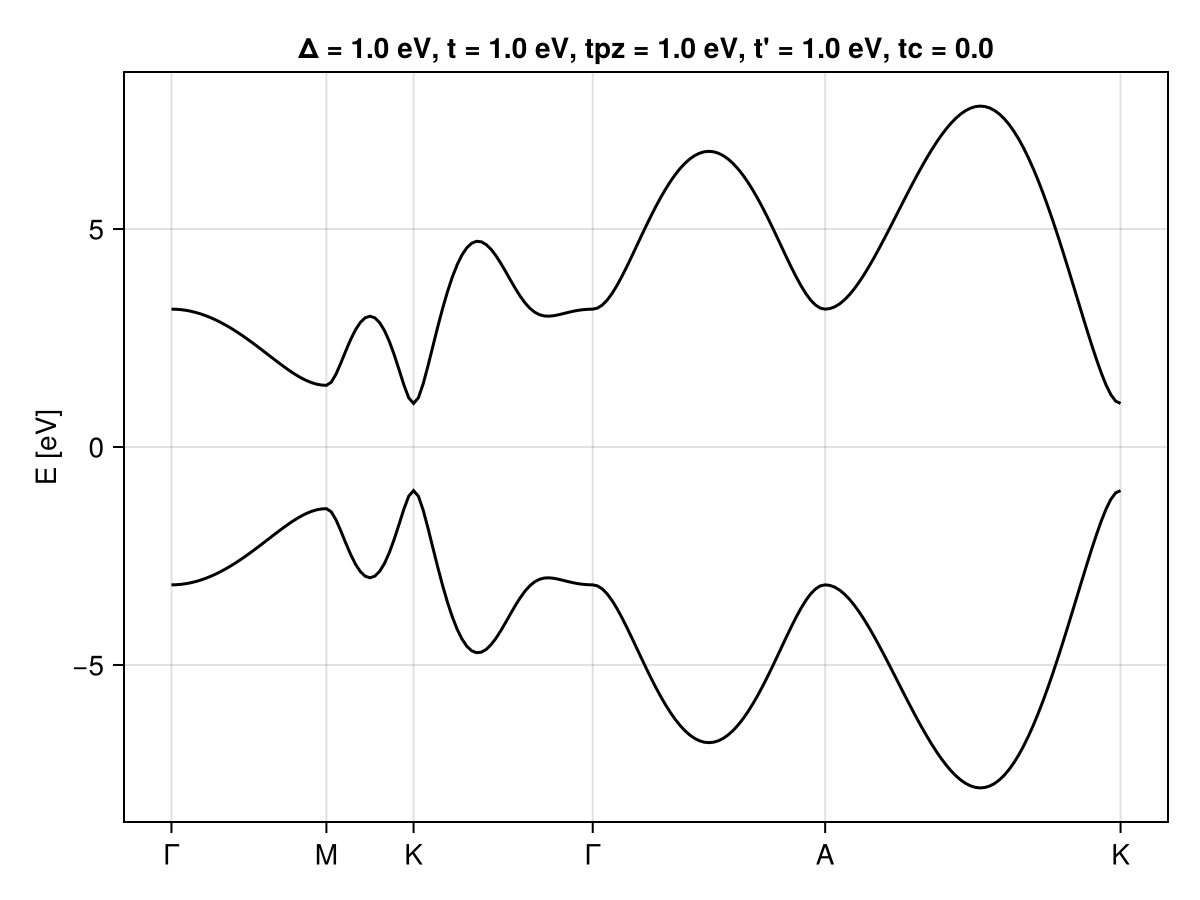

In [292]:
vals, fig = bands_ferroaxial_Gamma_M_K( modelpresets(; μ =0, t =1 ,tp =1, Δ = 1, tpz = 1, tc = 0));
fig

In [314]:
# bands_ferroaxial( modelpresets(; μ =0, t =1 ,tp =0, Δ = 0));


In [31]:
it = 0

0

In [293]:

using DelimitedFiles
storemat = "/Users/fernandopenaranda/Desktop/TempFigs/bandstc0"
writedlm(storemat *"_.csv", yvals, ',')

save(storemat*"_bandsfigtc0.png", fig)



CairoMakie.Screen{IMAGE}


## Fij kline

In [266]:
Fij_Gamma_M_K(p, comp_pres, dirF1, dirF2, band; a = 1) = Oij_Gamma_M_K(Optics_in_the_length_gauge.F,p,  comp_pres, dirF1, dirF2, band, a = a )
function Oij_Gamma_M_K(func, p, comp_pres, dirF1, dirF2, band; a = 1)
    N = 400    #kpoints
    mysimpath = [Γ, M .+ 1e-3 , K .+ 1e-3, Γ .+ 1e-3, A .+ 1e-3 , K]
    Fab(comp_pres, q, band) = func(comp_pres, q, dirF1, dirF2)[band]
    ks = interpolate(mysimpath, N)
    ticks_vals = [Fab(comp_pres, kpoint, 1 ) for kpoint in mysimpath]
    
    xvals = 1:length(ks)
    yvals_1 = [Fab(comp_pres, q, 1 ) for q in ks]
    yvals_2 = [Fab(comp_pres, q, 2) for q in ks]
    
    # position = [findmin(abs.(x .- yvals_1))[2] for x in ticks_vals]
    position =  [1, 66, 103, 178, 275, 398]
    println(position)
    xticks = (vcat(position[1:5],[xvals[end]]), ["Γ", "M", "K", "Γ", "A", "K"]) 
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "F$(dirF1)$(dirF2) [Å³]",  title = "Δ = $(p.Δ) eV, t = $(p.t) eV, tp = $(p.tpz) eV, t' = $(p.tp) eV, tc = $(p.tc) eV, QM on = $(comp_pres.QM_switch)",  xticks=xticks)
    lines!(ax, xvals, yvals_1, color = :red, label = "Lower band")
    scatter!(ax, xvals, yvals_1, color = :red)#, label = "Lower band")
    lines!(ax, xvals, yvals_2, color = :black, label = "Uper band")
    
    xlims!(ax, 1, N)
    if maximum(abs.(yvals_1))< 1e-6
        ylims!(ax, -1e-15,1e-15)
    end
    ylims!(ax, -0.07,0.07)
    axislegend(ax, position = :lt)
    return yvals_1, yvals_2, fig
end


Oij_Gamma_M_K (generic function with 1 method)

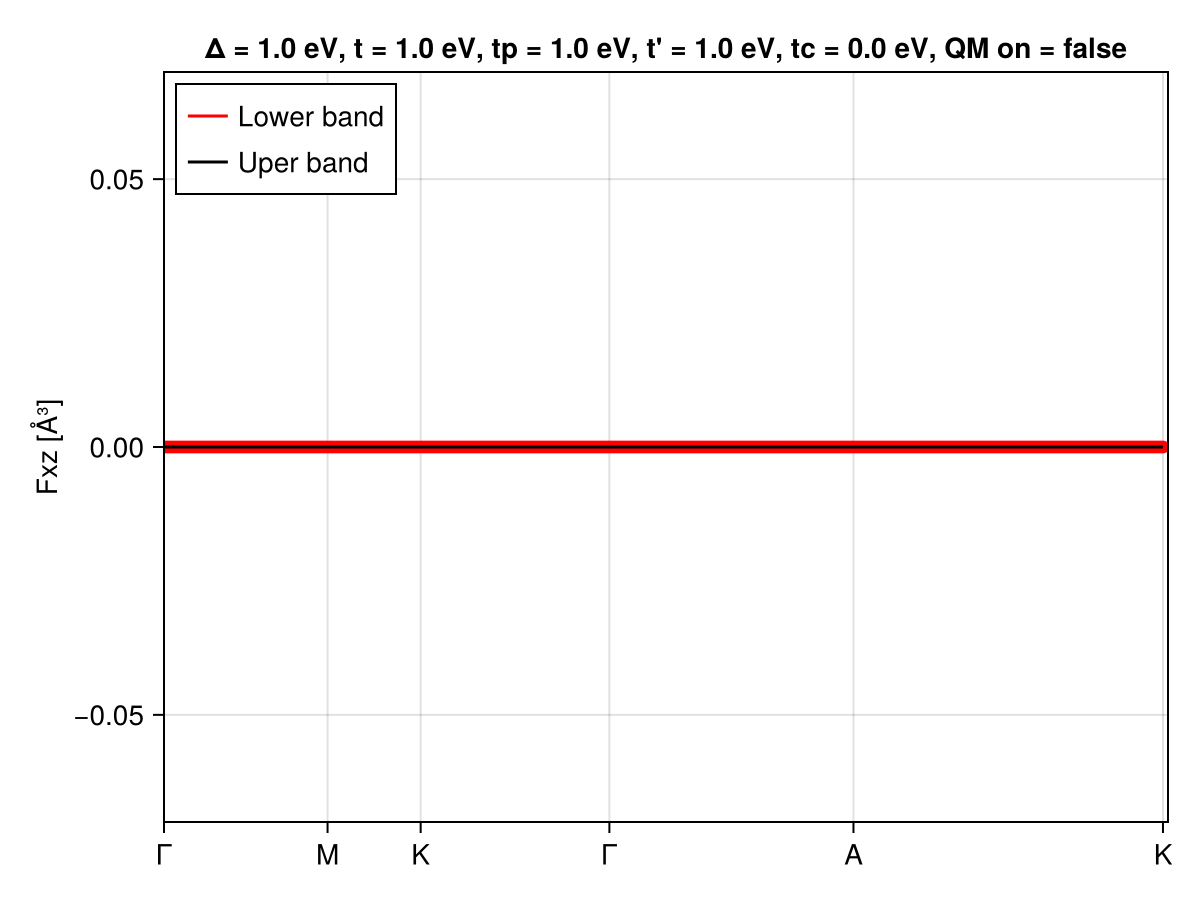

In [308]:
band = 1
a = 1.0
R1, R2, R3, δ1, δ2, δ3 = lattice_vectors(a)
Rs = [R1,R2,R3]

p = modelpresets(; μ = 1, t = 1 ,tp = 1, Δ =1, tpz = 1, tc = 0.3)
kws = (Ω_MM_switch = true, QM_switch = false)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);

dir1 = :x
dir2 = :z
# Method reusing the OMM
yvals0_1, yvals0_2, fig = Oij_Gamma_M_K(Optics_in_the_length_gauge.F, p, comp_pres, dir1, dir2, 1)
fig


In [309]:
using DelimitedFiles
storemat = "/Users/fernandopenaranda/Desktop/TempFigs/yvalsOmmtc0"
writedlm(storemat *"_$(String(dir1))$(String(dir2)).csv", [yvals0_1, yvals0_2], ',')

save(storemat*"_ommtc0_fig.png", fig)

CairoMakie.Screen{IMAGE}


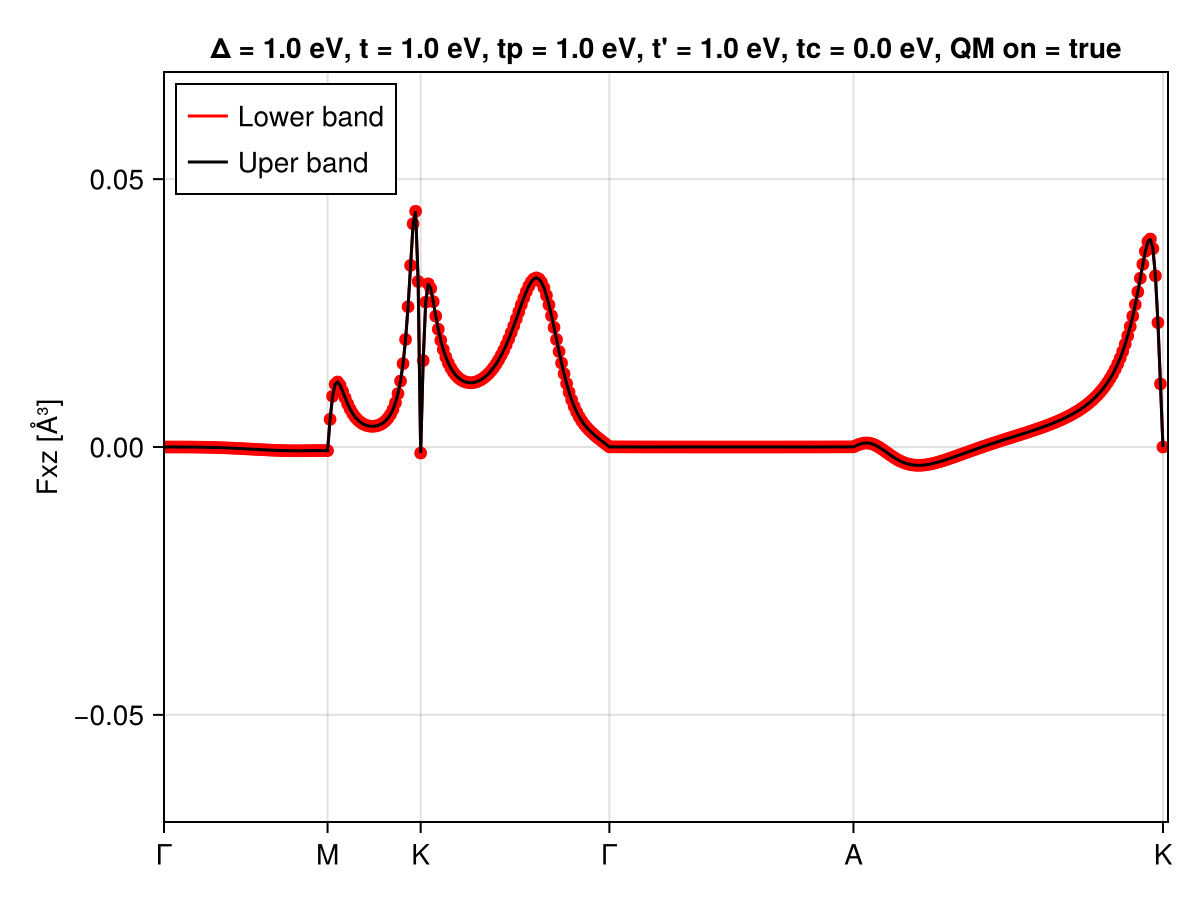

In [301]:
#Method sum rule
kws = (Ω_MM_switch = true, QM_switch = true)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);
yvals_0, yvals_1, fig = Oij_Gamma_M_K(Optics_in_the_length_gauge.F, p, comp_pres, dir1, dir2, 1);
fig

In [302]:
kws = (Ω_MM_switch = true, QM_switch = true)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);
yvalfull1, yvalfull2, fig = Oij_Gamma_M_K(Optics_in_the_length_gauge.F, p, comp_pres, dir1, dir2, 1);
kws = (Ω_MM_switch = true, QM_switch = false)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);
yvalsomm1, yvalsomm2, fig = Oij_Gamma_M_K(Optics_in_the_length_gauge.F, p, comp_pres, dir1, dir2, 1);

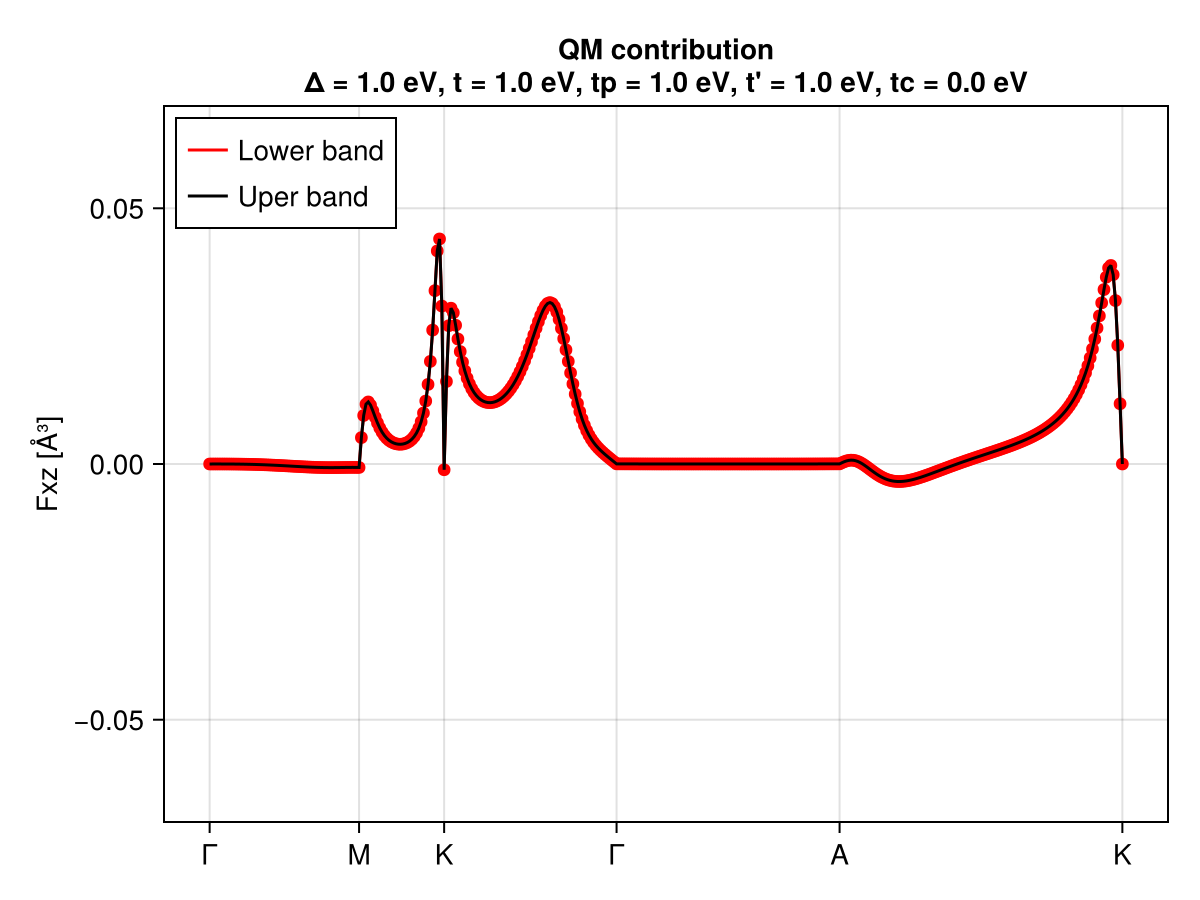

In [303]:
position =  [1, 66, 103, 178, 275, 398]
# fig = Figure(); ax = Axis(fig[1,1]); lines!(ax, yvalfull-yvalsomm)

xticks = (vcat(position[1:5],position[end]), ["Γ", "M", "K", "Γ", "A", "K"]) 
fig = Figure(); ax = Axis(fig[1,1], ylabel = "F$(dir1)$(dir2) [Å³]",  title = "QM contribution
Δ = $(p.Δ) eV, t = $(p.t) eV, tp = $(p.tpz) eV, t' = $(p.tp) eV, tc = $(p.tc) eV",  xticks=xticks)
lines!(ax,1:398, yvalfull1-yvalsomm1, color = :red, label = "Lower band")
scatter!(ax, 1:398, yvalfull1-yvalsomm1, color = :red)#, label = "Lower band")
lines!(ax,1:398,yvalfull2-yvalsomm2, color = :black, label = "Uper band")


ylims!(ax, -0.07,0.07)
axislegend(ax, position = :lt)


fig

In [304]:
using DelimitedFiles
storemat = "/Users/fernandopenaranda/Desktop/TempFigs/yvalsqmtc0"
writedlm(storemat *"_$(String(dir1))$(String(dir2)).csv", [yvalfull1-yvalsomm1,yvalfull2-yvalsomm2], ',')

save(storemat*"_qmtc0_fig.png", fig)

CairoMakie.Screen{IMAGE}


## K resolved plots

In [13]:
function k_mesh_evals(quantity, p, R1, R2, R3, c_symb::Symbol; u0 = 0,  botbounds = [-0.5,-0.5], topbounds = [0.5,0.5], kpoints = 100)
    Gs = dualbasis([R1,R2,R3])
    N = floor(Int, kpoints^(1/3))
    uas = range(botbounds[1], topbounds[1], length=N)
    ubs = range(botbounds[2], topbounds[2], length=N)
    c = Optics_in_the_length_gauge.symb_to_ind(c_symb)
    u_param(ua,ub, c) = ifelse(c == 1, [u0,ua,ub], ifelse(c == 2, [ua,u0,ub], [ua,ub,u0]))
    aux_f(ua,ub,c) = Optics_in_the_length_gauge.transform_k(SVector(ua,ub,c), Gs)
    a, b = setdiff(1:3, [c])
    ka = [Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c), Gs)[a] for ua in uas, ub in ubs]
    kb = [Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c), Gs)[b] for ua in uas, ub in ubs]
    f(ua,ub) = quantity(p, Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c),Gs))
    Z = [f(ua,ub) for ua in uas, ub in ubs]
    return (a,b), ka, kb, Z
end

function plot_kresolved(kx, ky, Z, u0; label = "f(a, b)", titlelab = "")
    fig = Figure(size = (600, 500))
    ax = Axis(fig[1, 1], xlabel="ka [1/Å]", ylabel="kb [1/Å]", title = titlelab * ", uz = $(u0)")
    cmap = :RdBu#reverse(cgrad(:grays))  # CairoMakie built-in colormap, light-to-dark blues
    hm = surface!(ax, kx, ky, zeros(size(Z)),
                color=Z,
                shading=NoShading,
                colormap=cmap,
                colorrange=(-maximum(abs,Z), maximum(abs,Z)))
    Colorbar(fig[1, 2], hm, label=label)
    # ylims!(ax, -2π-π/2, 2π+π/2)
    fig
end

plot_kresolved (generic function with 1 method)

In [254]:
# compute k mesh

T = 10
u0 = 0.00001

a = 1.0
Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2, 0], a .* [0,0,1])
R1 = Rs[1]
R2 = Rs[2]
R3 = Rs[3]

using Brillouin, Bravais, BZpaths

kws = (dirj = :x, dirE = :z, dirB = :x, T = T,
    evals = evals, integration_method = :montecarlo, fermi_surface = true, botbounds =xbounds, 
    topbounds = -xbounds, Ω_MM_switch = false, PS_switch = true, QM_switch = true)

p = modelpresets(; μ = 1 , t = 1 ,tp = 0, Δ = 0)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...)

dirs, kx, ky, Z = k_mesh_evals(Optics_in_the_length_gauge.integrand_quantum_contribution_q, 
    comp_pres, R1, R2, R3, :z, u0 =u0, botbounds =  [-0.55,-0.55], topbounds = [-0.45,-0.45], kpoints = 100000);

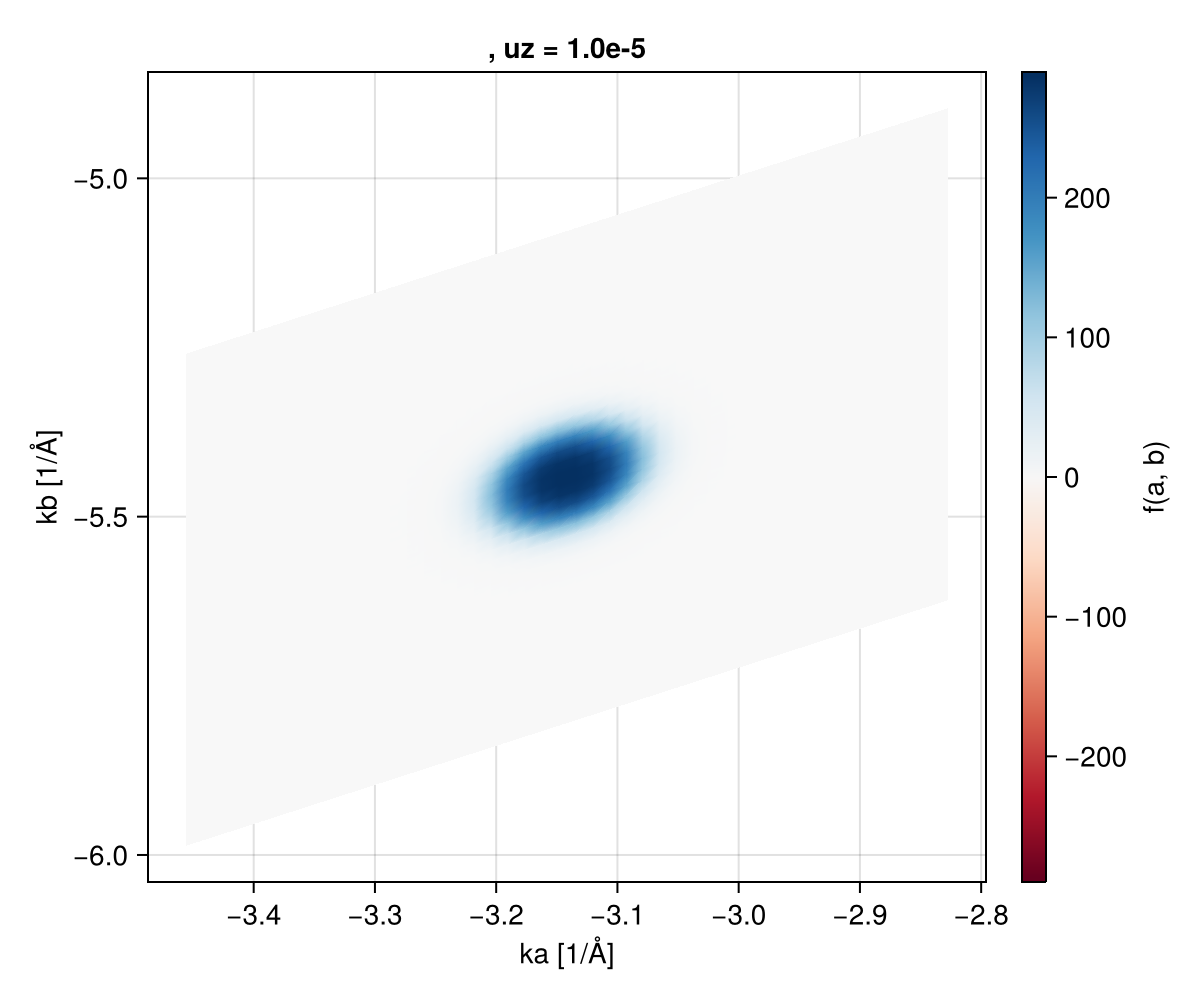

In [255]:
plot_kresolved(kx,ky,Z, u0)

## Sigma abc calculations

In [314]:
evals = 10000
mu = 0
murange = collect(0:0.5:3)
xbounds = 1 .* [-0.5,-0.5, -0.5]
T = 10
kws = (dirj = :x, dirE = :z, dirB = :x, T = T,
    evals = evals, integration_method = :montecarlo, fermi_surface = false, botbounds =xbounds, 
    topbounds = -xbounds, Ω_MM_switch = false, PS_switch = true, QM_switch = true)
#_________________________________________________________________________________________



(dirj = :x, dirE = :z, dirB = :x, T = 10, evals = 10000, integration_method = :montecarlo, fermi_surface = false, botbounds = [-0.5, -0.5, -0.5], topbounds = [0.5, 0.5, 0.5], Ω_MM_switch = false, PS_switch = true, QM_switch = true)

In [316]:
p = modelpresets(; μ = 3, t = 1 ,tp = 1, Δ =1, tpz = 1, tc = 0.3)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...)
σ_ijk_A1_qc =  quantum_contribution(comp_pres) 

-0.3506360128999635

## Sweepm

In [320]:
function musweep(murange; T = 10, evals = 5000, t = 1, tp = 0, tpz =0, tc = 0.3, Δ = 1, fs = false, oswitch = false, psswitch = true, qmswitch = true)
    s = []
    for mu in murange
        comp_pres = sigma_abc_ferroaxial_wrapper_3d(modelpresets(; μ = mu, t = t ,tp = tp, tpz= tpz, tc =tc, Δ = Δ), 
            dirj = :x, dirE = :z, dirB = :x, T = T, evals = evals, integration_method = :montecarlo, 
            fermi_surface = fs, botbounds = [-0.5,-0.5,-0.5], topbounds = [0.5,0.5,0.5],
            Ω_MM_switch = oswitch, PS_switch = psswitch, QM_switch = qmswitch);
        push!(s, quantum_contribution(comp_pres))
    end
    return murange, s
end


musweep (generic function with 1 method)

In [337]:
kws = (T = 10, evals = 640000, t = 1 ,tp = 1, Δ =1, tpz = 1, tc = 0.3, 
    fs = false, oswitch = true, psswitch = true, qmswitch = true)
mustest, sumsstest = musweep(range(0,3, length = 5); kws...)

(0.0:0.75:3.0, Any[0.0, -4.219847596113686e-80, -0.02154438681356173, 0.11846333485071338, 0.03539480646916302])

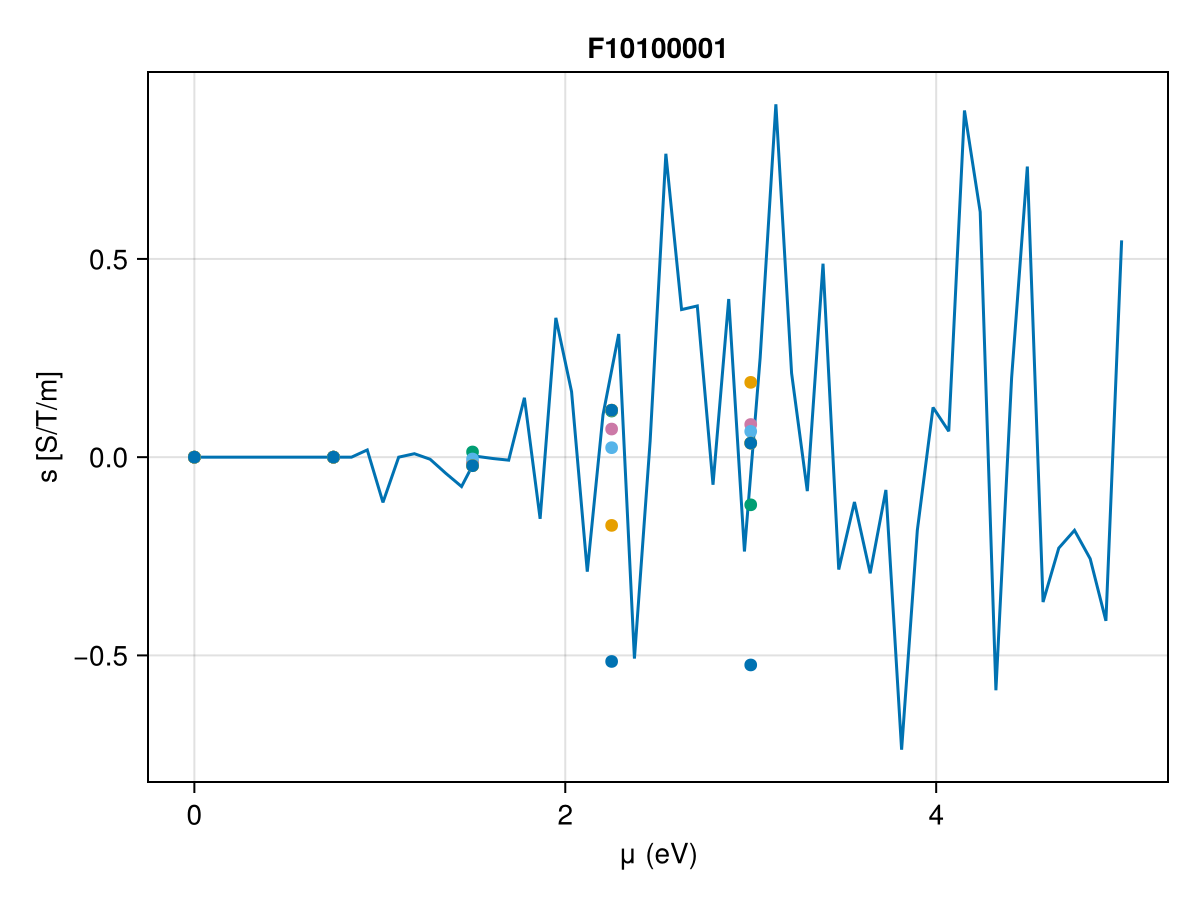

In [341]:
# fig = Figure(); ax = Axis(fig[1,1], xlabel = "μ (eV)", 
#     ylabel = "s [S/T/m]", title = "F$(kws[1])$(kws[2])$(kws[3])")
scatter!(ax, [mu for mu in mustest], [s for s in sumsstest])
# ylims!(ax, -1.5,1.5)
fig


In [175]:

kws = (T = 2, evals = evals, t = 1, tp = 0, Δ = 1, fs = false, oswitch = false, psswitch = true, qmswitch = true)
mus1n, sumss1n = musweep(range(0,4, length = 60); kws...)

Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo 

(0.0:0.06779661016949153:4.0, Any[-1.8014751408592234e-49, 133.08644060325943, -0.2289775723704874, 1.304799002016346, -1.4210235059968568, 1.464096516172152, -0.1655540743447662, -0.224275825793598, -0.08706127415001431, -0.087695750015193  …  -6.911881750972703e-5, 0.00025385200995188214, -7.718868897696502e-5, -6.524657796921352e-8, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [154]:
kws = (T = 2, evals = evals, t = 1, tp = 0, Δ = 1, fs = false, oswitch = true, psswitch = true, qmswitch = true)
mus2, sumss2 = musweep(range(0,4, length = 30); kws...)

Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration


(0.0:0.13793103448275862:4.0, Any[2.343733962419136e-132, -0.019019317995394296, 5.409185942723516, -2.321693461178733, -0.980741629817141, 0.6339128938470195, 0.07414461741259083, -0.05377033633433036, -0.032540363655788086, -0.024904938321208138  …  -0.004832387897067995, -0.00033894356990574274, 0.00031518366045450486, 0.0005692912159066454, 0.00028176504343828477, 8.378543067385263e-5, 2.464090720925085e-6, 0.0, 0.0, 0.0])

In [176]:
kws = (T = 2, evals = evals, t = 1, tp = 1, Δ = 1, fs = false, oswitch = true, psswitch = true, qmswitch = true)
mus3n, sumss3n = musweep(range(0,4, length = 60); kws...)

Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo 

(0.0:0.06779661016949153:4.0, Any[-1.7055319675563784e-267, -1.179772720627215e-96, -3.1019284737772517e-13, 6.421149511588863e-9, 8.774014924313122e-20, 6.166715820643265e-10, -1.9104493399437266e-9, 2.970421974852288, 6.56760388516288e-11, 0.0004918563270744038  …  1.8103000306074162, 0.8587100587026667, 1.3358064943439418, 0.5869012922349303, 0.6599031489454174, -1.5111809322746195, 1.429654094514587, 0.4172925019844951, 0.7016215975809869, 0.09336963295608261])

In [156]:
kws = (T = 2, evals = evals, t = 1, tp = 1, Δ = 1, fs = false, oswitch = false, psswitch = true, qmswitch = true)
mus4, sumss4 = musweep(range(0,4, length = 30); kws...)

Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration


(0.0:0.13793103448275862:4.0, Any[0.0, -6.003002905680651e-7, 1.3236684583039357e-7, -0.007853666894063865, 1.4496039552995823e-6, 0.036760902340429134, -7.959658482958817e-11, 1.5457872033042864e-5, -9.633115875996634, 24.546405278382238  …  2.007868765403426, 4.406010247349586, 3.888377551529731, 0.04600052780945585, -1.9056472839357828, 0.6899853145465145, 0.7567325536714592, 0.22512518603100573, 0.48448540027174103, 1.0910330478836825])

In [ ]:
kws = (T = 2, evals = evals, t = 1, tp = 1, Δ = 1, fs = false, oswitch = false, psswitch = true, qmswitch = false)
mus5, sumss5= musweep(range(0,4, length = 30); kws...)

In [ ]:
kws = (T = 2, evals = 10, t = 1, tp = 0, Δ = 1, fs = false, oswitch = false, psswitch = true, qmswitch = true)
mus6, sumss6 = musweep(range(0,4, length = 30); kws...)

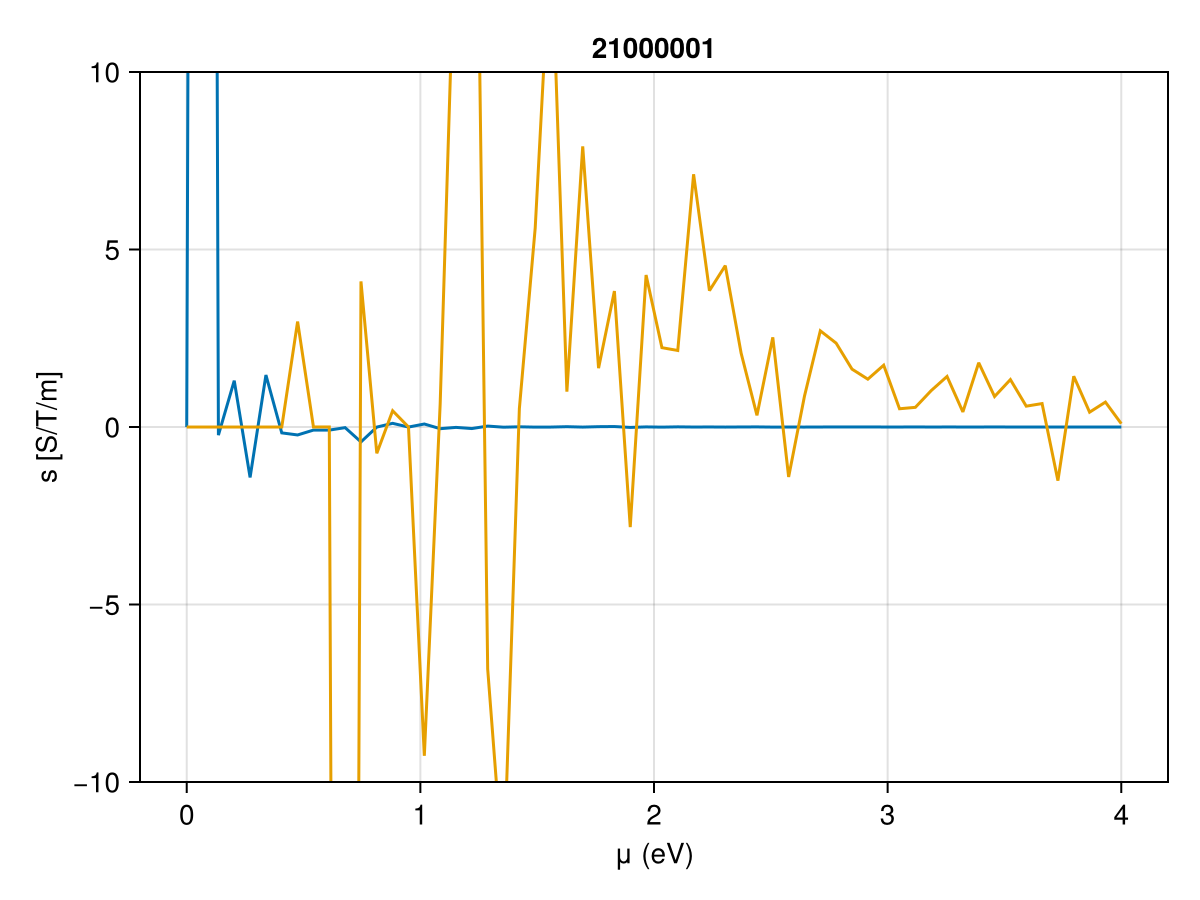

In [180]:
fig = Figure(); ax = Axis(fig[1,1], xlabel = "μ (eV)", ylabel = "s [S/T/m]", title = "$(kws[1])$(kws[2])$(kws[3])")
lines!(ax, [mu for mu in mus1n], [s for s in sumss1n])
lines!(ax, [mu for mu in mus3n], [s for s in sumss3n])
ylims!(ax, -10,10)
fig


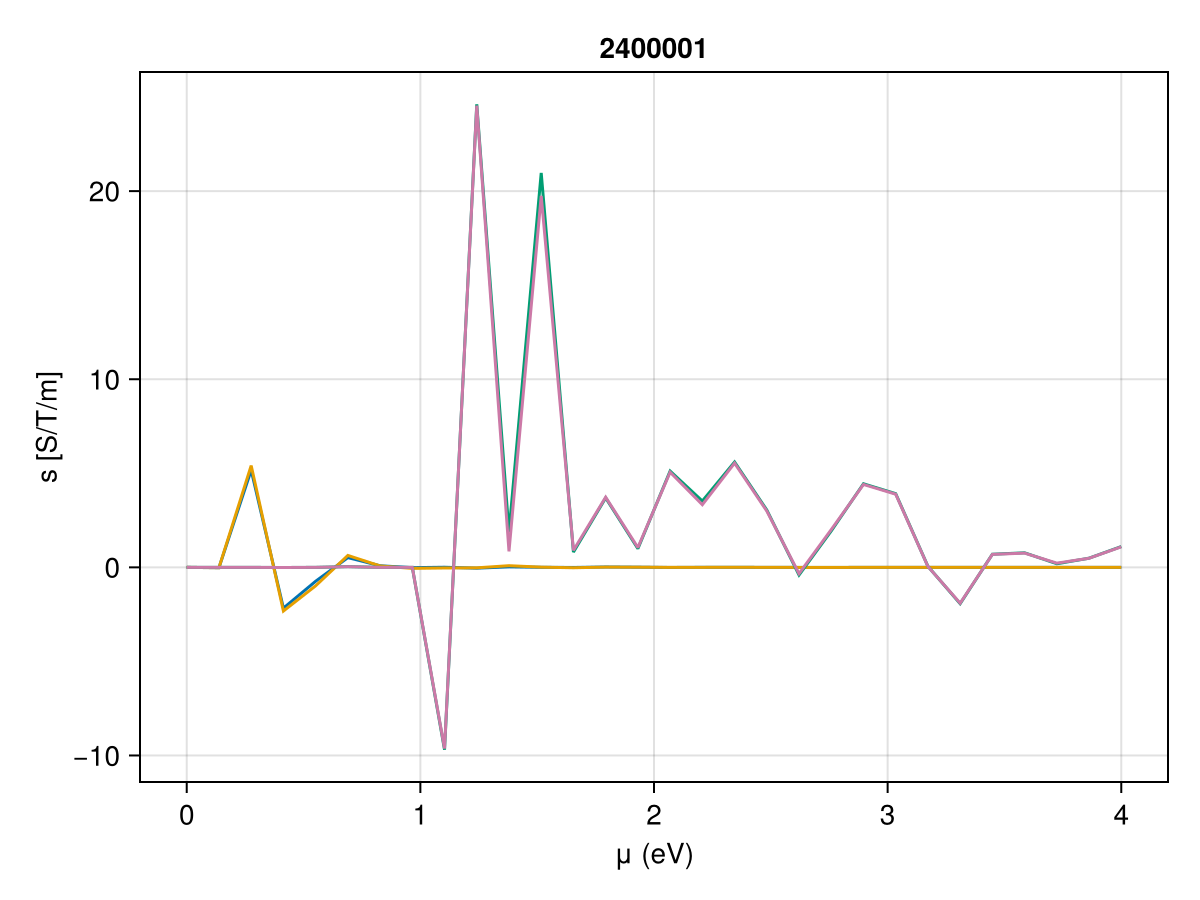

In [159]:
fig = Figure(); ax = Axis(fig[1,1], xlabel = "μ (eV)", ylabel = "s [S/T/m]", title = "$(kws[1])$(kws[2])$(kws[3])")
lines!(ax, [mu for mu in mus1], [s for s in sumss1])
lines!(ax, [mu for mu in mus2], [s for s in sumss2])
lines!(ax, [mu for mu in mus2], [s for s in sumss3])
lines!(ax, [mu for mu in mus2], [s for s in sumss4])


fig

In [ ]:
it +=1
using DelimitedFiles
storemat = "/Users/fernandopenaranda/Desktop/TempFigs/integrated"
writedlm(storemat *"_xzx_Fcorrected_$(it).csv", yvals, ',')
save(storemat*"_$(it)_fig.png", fig)



## K-resolved calculations

In [17]:
using Brillouin, Bravais, BZpaths

In [34]:
function k_mesh_evals(quantity, p, R1, R2, R3, c_symb::Symbol; u0 = 0,  botbounds = [-0.5,-0.5], topbounds = [0.5,0.5], kpoints = 100)
    translator_Gs =  [0.5,0,0]
    Gs = dualbasis(Rs)
    println("Gs: ", Gs)
    N = floor(Int, kpoints^(1/3))
    uas = range(botbounds[1], topbounds[1], length=N)
    ubs = range(botbounds[2], topbounds[2], length=N)
    c = Optics_in_the_length_gauge.symb_to_ind(c_symb)
    u_param(ua,ub, c) = ifelse(c == 1, [u0,ua,ub], ifelse(c == 2, [ua,u0,ub], [ua,ub,u0]))
    # aux_f(ua,ub,c) = Optics_in_the_length_gauge.transform_k(SVector(ua,ub,c), nGs)
    a, b = setdiff(1:3, [c])
    ka = [Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c), Gs)[a] for ua in uas, ub in ubs]
    kb = [Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c), Gs)[b] for ua in uas, ub in ubs]
    f(ua,ub) = quantity(p, Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c),Gs)+translator_Gs + [pi/2,0,0])
    Z = [f(ua,ub) for ua in uas, ub in ubs]
    return (a,b), ka, kb, Z
end

function plot_kresolved(kx, ky, Z, u0; label = "f(a, b)", titlelab = "", colorrange = missing)
    fig = Figure(size = (600, 500))
    ax = Axis(fig[1, 1], xlabel="ka [1/Å]", ylabel="kb [1/Å]", title = titlelab * ", uz = $(u0)")
    cmap = :RdBu#reverse(cgrad(:grays))  # CairoMakie built-in colormap, light-to-dark blues
    if isa(colorrange, Missing) == true
        colrange = (-maximum(abs,Z), maximum(abs,Z))
    else
        colrange = colorrange
    end
    hm = surface!(ax, kx, ky, zeros(size(Z)),
                color=Z,
                shading=NoShading,
                colormap=cmap,
                colorrange=colrange)
    Colorbar(fig[1, 2], hm, label=label)
    #xlims!(ax, -2π-π/2, 2π+π/2)
    fig
end




plot_kresolved (generic function with 1 method)

In [44]:
# compute k mesh
dirF1 = :x
dirF2 = :z
u0 = 0.
mypoints = 10000
 band = 1
 a = 1.0

R1, R2, R3, δ1, δ2, δ3 = lattice_vectors(a)
Rs = [R1,R2,R3]

Fab(comp_pres, q) = Optics_in_the_length_gauge.F(comp_pres, q, dirF1, dirF2)[band]

kws = (PS_switch = true, QM_switch = true, T = 100)
kws_noQM = (PS_switch = true, QM_switch = false)

p = modelpresets(; μ = 0, t = 1 ,tp = 1, Δ = 1, tpz = 1)

comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);
comp_pres_noQM = sigma_abc_ferroaxial_wrapper_3d(p; kws_noQM...);

In [45]:
R1, R2, R3, δ1, δ2, δ3 = lattice_vectors(a)

([1.5, 0.8660254037844386, 0.0], [1.5, -0.8660254037844386, 0.0], [0.0, 0.0, 1.0], [0.5, 0.8660254037844386, 0.0], [0.5, -0.8660254037844386, 0.0], [-1.0, 0.0, 0.0])

### DOS

In [99]:
# compute k mesh
dirs, kx, ky, Z = k_mesh_evals(Optics_in_the_length_gauge.integrand_quantum_contribution_q, 
    comp_pres, R1, R2, R3, :z, u0 =u0, botbounds = 2.2 .* [-0.5,-0.5], topbounds = 2.2 .* [0.5,0.5], kpoints = 500000);

Gs: [[2.0943951023931953, 3.6275987284684357, -0.0], [2.0943951023931953, -3.6275987284684357, -0.0], [-0.0, -0.0, 6.283185307179586]]


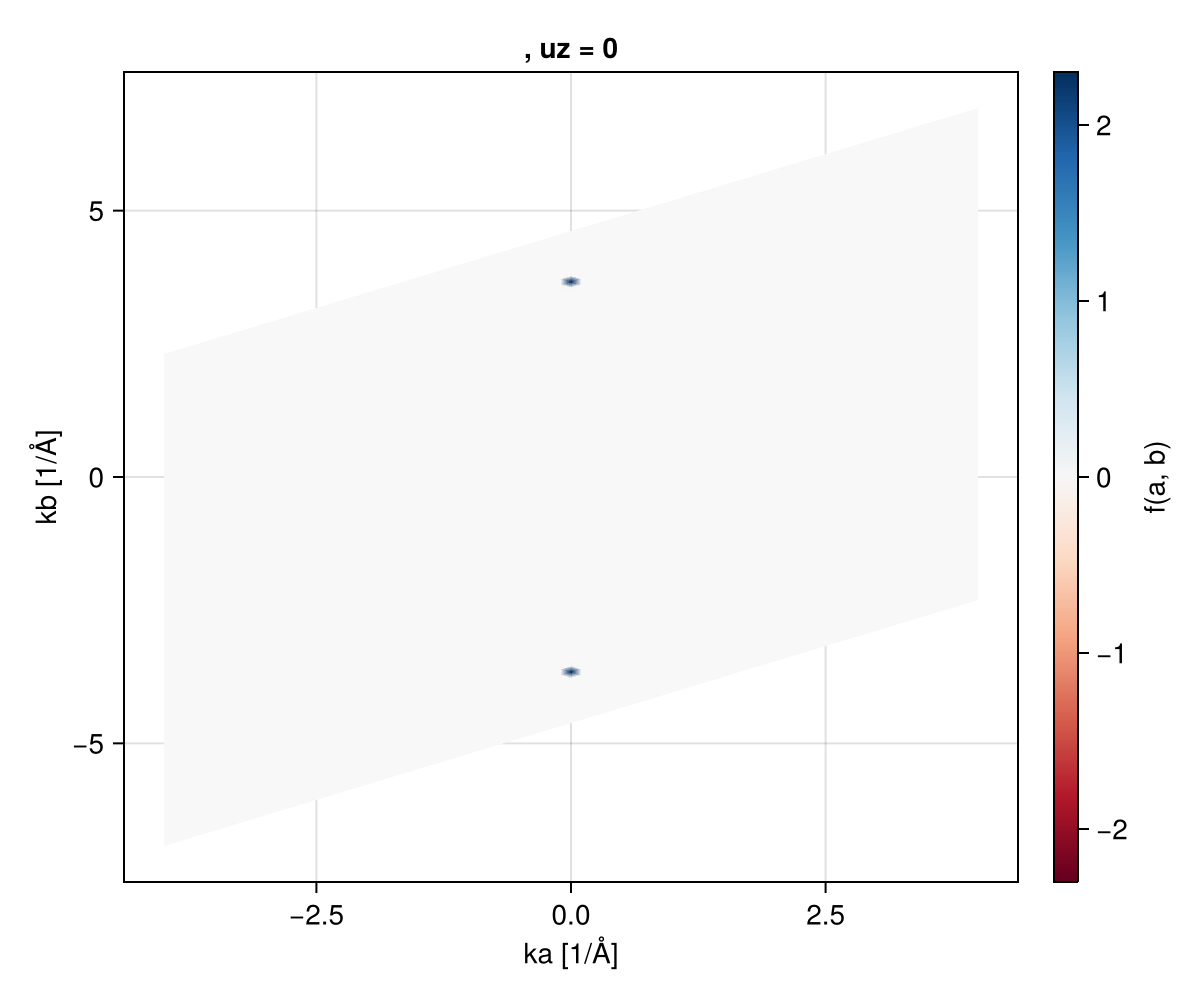

In [36]:
plot_kresolved(kx,ky,Z, u0) 

### F contribution

In [46]:
# compute k mesh

R1, R2, R3, δ1, δ2, δ3 = lattice_vectors(a)

# dirs, kx, ky, Z = k_mesh_evals(Fab, comp_pres, R1, R2, R3, :z, u0 =u0, botbounds = 2 .* [-0.5,-0.5], topbounds = 2 .* [0.5,0.5], kpoints = points);
dirs, kx, ky, Z = k_mesh_evals(Fab,
    comp_pres, R1, R2, R3, :z, u0 =0, botbounds = 1 .* [-0.5,-0.5], topbounds = 1 .* [0.5,0.5], kpoints = mypoints);

Gs: [[2.0943951023931953, 3.6275987284684357, -0.0], [2.0943951023931953, -3.6275987284684357, -0.0], [-0.0, -0.0, 6.283185307179586]]


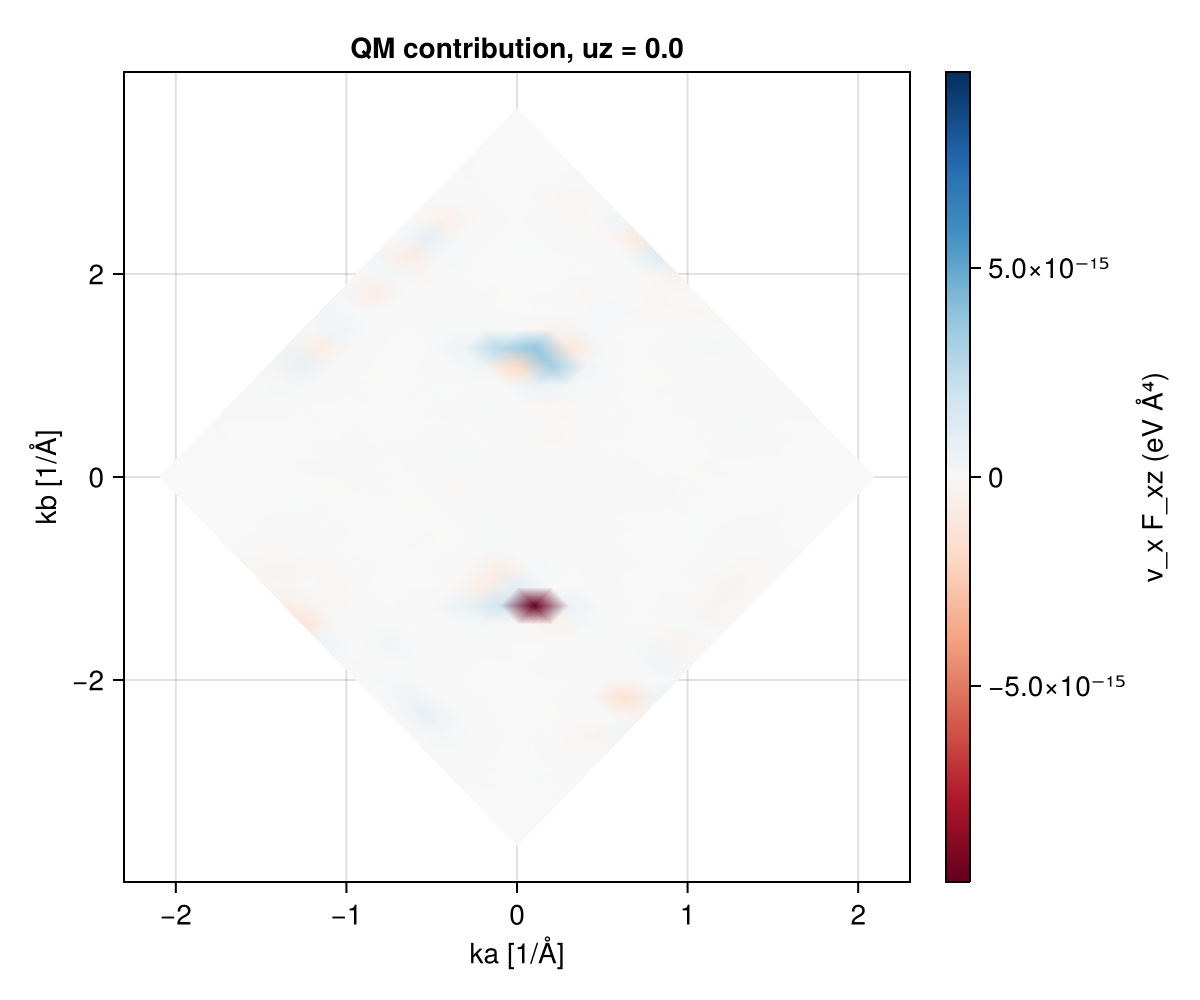

In [47]:
plot_kresolved(kx,ky,Z , u0, titlelab = "QM contribution", label = "v_x F_$(dirF1)$(dirF2) (eV Å⁴)") 

In [134]:
sum(Z)

135.0710565574812

In [57]:
dirs, kx, ky, Z_noQM = k_mesh_evals(Fab, 
    comp_pres_noQM, R1, R2, R3, :z, u0 =u0, botbounds = 4 .* [-0.5,-0.5], topbounds = 4 .* [0.5,0.5], kpoints = points);

UndefVarError: UndefVarError: `u0` not defined

In [516]:
sum(Zfull)

5.684341886080802e-14

#### difference1

In [167]:
Fabdifference(comp_pres, q) = Fab(comp_pres, q) + Fab(comp_pres, -q)

Fabdifference (generic function with 1 method)

In [177]:
# compute k mesh

dirs, kx, ky, Zdif = k_mesh_evals(Fabdifference, 
    comp_pres, R1, R2, R3, :z, u0 =u0, botbounds = 1 .* [-0.5,-0.5], topbounds = 1 .* [0.5,0.5], kpoints = points);

    

[[3.6275987284684357, -6.283185307179586, 0.0], [3.6275987284684357, 6.283185307179586, -0.0], [-0.0, 0.0, 6.283185307179586]]


((1, 2), [-3.6275987284684357 -3.5905824149126353 … -0.03701631355580037 0.0; -3.5905824149126353 -3.553566101356835 … 0.0 0.03701631355580037; … ; -0.03701631355580037 0.0 … 3.553566101356835 3.5905824149126353; 0.0 0.03701631355580037 … 3.5905824149126353 3.6275987284684357], [0.0 0.06411413578754699 … 6.21907117139204 6.283185307179586; -0.06411413578754699 0.0 … 6.154957035604492 6.21907117139204; … ; -6.21907117139204 -6.154957035604492 … 0.0 0.06411413578754699; -6.283185307179586 -6.21907117139204 … -0.06411413578754699 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

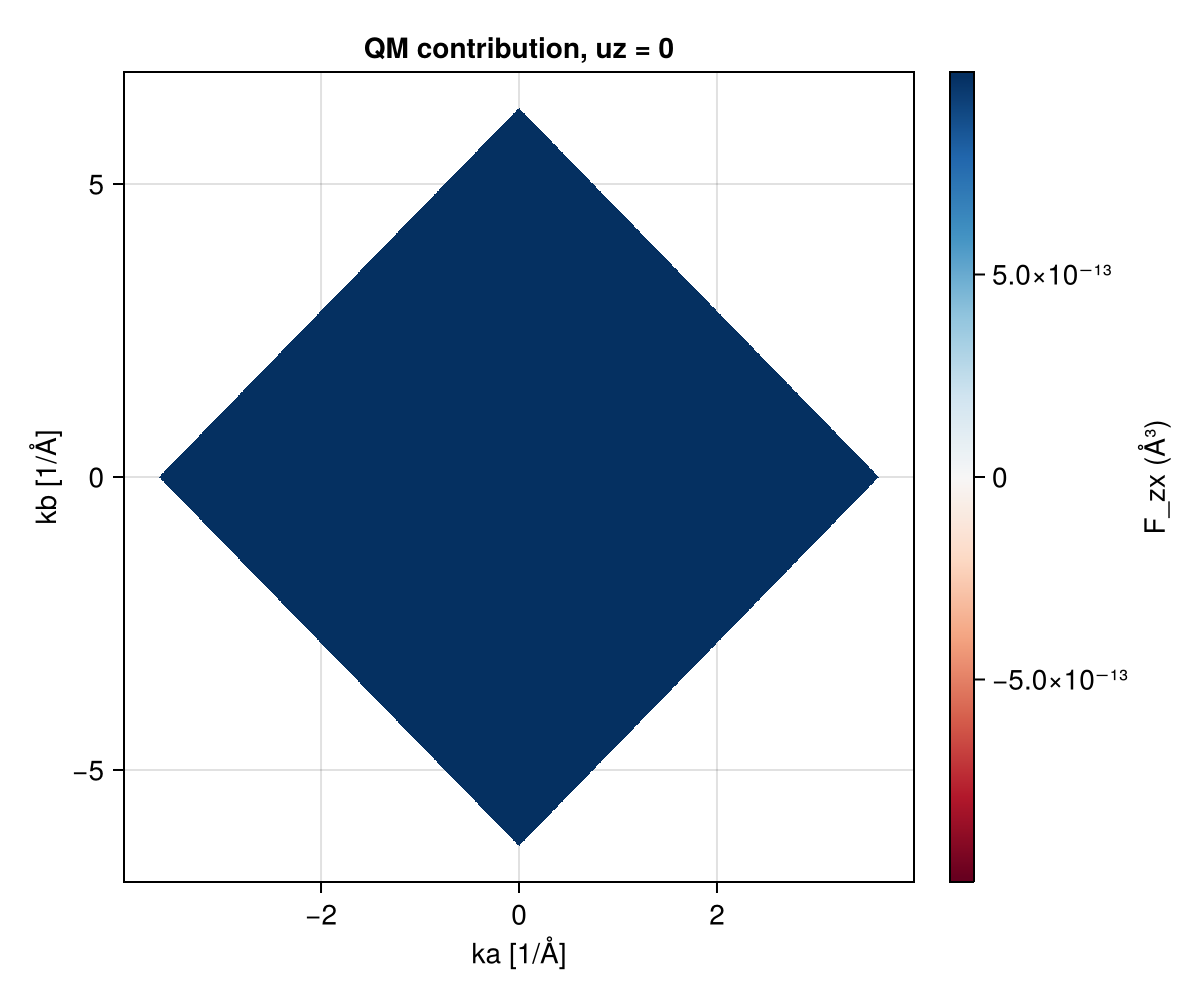

In [178]:
plot_kresolved(kx,ky,Zdif .+ 1e-12, u0, titlelab = "QM contribution", label = "F_$(dirF1)$(dirF2) (Å³)") 

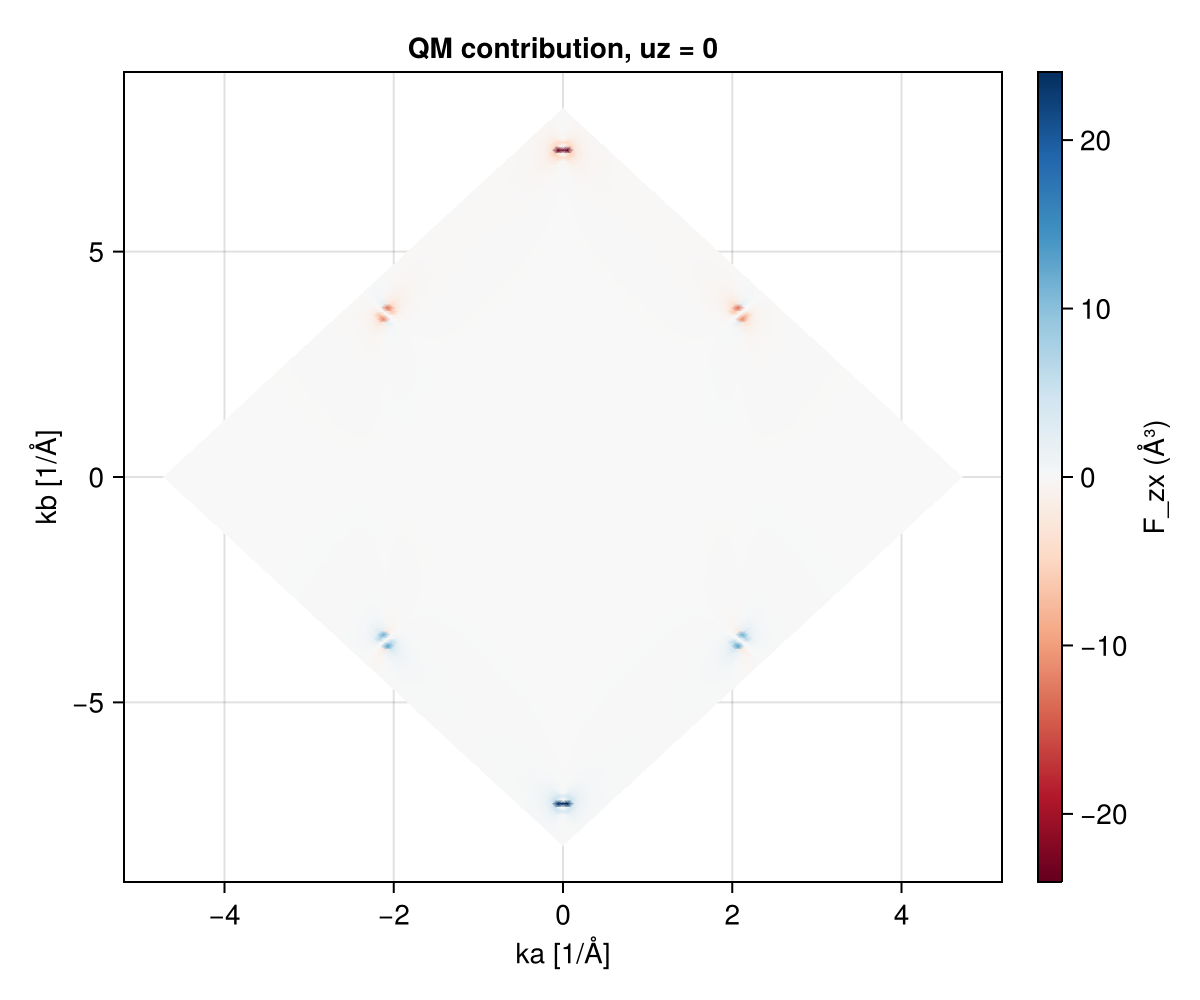

In [154]:
plot_kresolved(kx,ky,Zfull, u0, titlelab = "QM contribution", label = "F_$(dirF1)$(dirF2) (Å³)") 

### Berry curvature on z

In [103]:
mypoints = 1000000
Omega(comp_press, q) = Optics_in_the_length_gauge.k_σij_anomalous_hall_3d(comp_press.dirJ, comp_press.dirE, comp_press.h(q),
     comp_press.nabla_h(q), comp_press.T, comp_press.gs)[band]
# compute k mesh
dirs, kx, ky, Omegaz = k_mesh_evals(Omega,
    comp_pres, R1, R2, R3, :z, u0 =0, botbounds = 2 .* [-0.5,-0.5], topbounds =2 .* [0.5,0.5], kpoints = mypoints);

Gs: [[2.0943951023931953, 3.6275987284684357, -0.0], [2.0943951023931953, -3.6275987284684357, -0.0], [-0.0, -0.0, 6.283185307179586]]


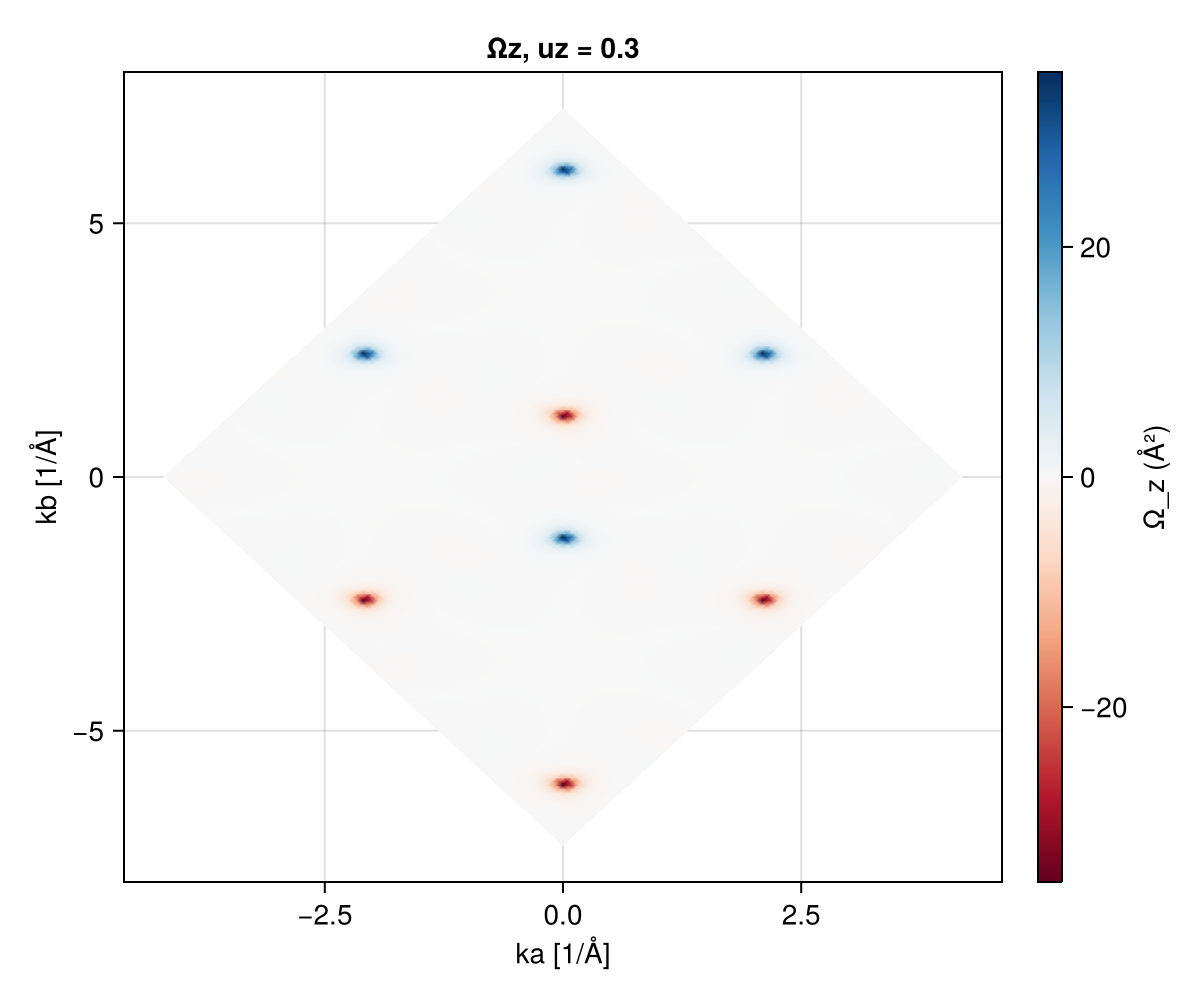

In [104]:
plot_kresolved(kx,ky, Omegaz, u0, titlelab = "Ωz", label = "Ω_z (Å²)") 

In [115]:
dirs, kx, ky, Omegaz = k_mesh_evals(Omega,
    comp_pres, R1, R2, R3, :z, u0 =0, botbounds = 1 .* [-0.5,-0.5], topbounds =1 .* [0.5,0.5], kpoints = mypoints);

UndefVarError: UndefVarError: `mypoints` not defined

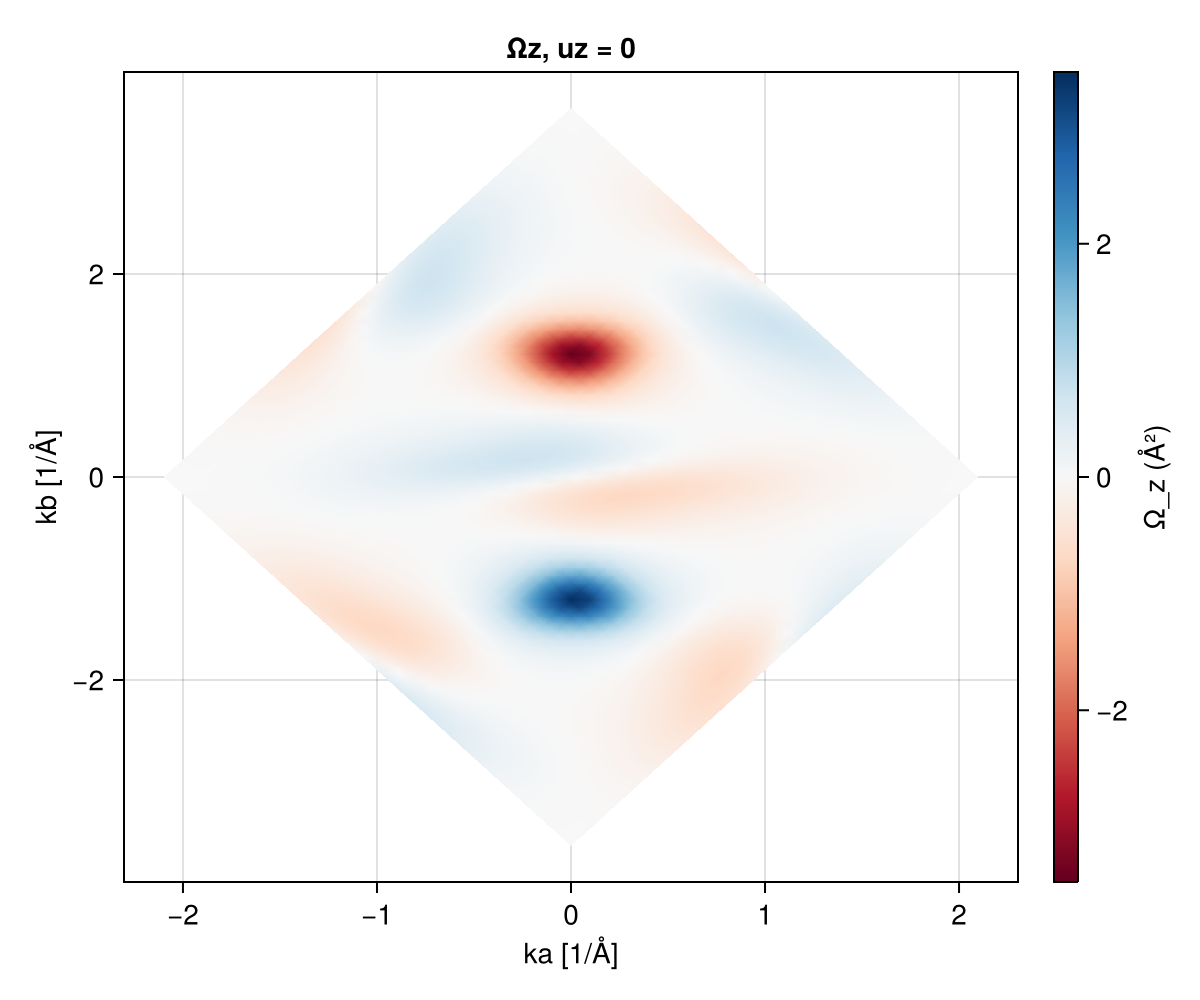

In [332]:
plot_kresolved(kx,ky, Omegaz, u0, titlelab = "Ωz", label = "Ω_z (Å²)") 